In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP
from src.sanity_checks import flag_remove_cat


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Sensitivity analysis

In [2]:
#parameters & constants
split_lowest = False
DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]

In [4]:
1991 / 242 * 365

3002.954545454545

In [6]:
2100 / 365 * 30

172.60273972602738

In [3]:
#load once labelled data
res_savename_lab = "merged_subtypes_post_processed_new_unit_std_labelled_reports_impacts_all_v111025"
split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix3 = suffix + "_v171025"
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix3+".gpkg"))

keep_appeals = [appeal for appeal in labelled_df["appealCode"].unique() if appeal not in drop_appeals]
labelled_df = labelled_df[labelled_df["appealCode"].isin(keep_appeals)]

In [4]:
#load extracted and matched data

models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
sims = ["fixed_impact_desc", "fixed_impact_desc2", "fixed_impact_desc3"]
models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile", "openai_gpt-oss-20b"]
rep_sims_names = {"sim1":f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_meta-llama_llama-4-scout-17b-16e-instruct_v271025{suffix}_v271025",
                  "sim2":f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc2_meta-llama_llama-4-scout-17b-16e-instruct_v271025{suffix}_v271025",
                  "sim3":f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc3_meta-llama_llama-4-scout-17b-16e-instruct_v271025{suffix}_v271025"}

mod_sims_names = {models[0]:f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{models[0]}_v271025{suffix}_v271025",
                  models[1]:f"merged_subtypes_post_processed_labelled_reports_{models[1]}_v271125{suffix}_v271125",
                  models[2]:f"merged_subtypes_post_processed_labelled_reports_{models[2]}_v271125{suffix}_v271125",
                  models[3]:f"merged_subtypes_post_processed_labelled_reports_{models[3]}_v271125{suffix}_v271125"}

filename_match = "matched_data_ws6qt-ws5ql-geo-valuepre-strict-nans_"

#filtering  and processing params
value_error_th = 0.1
sim_th = 0.5
filter_flags = ["flag_unit_nonstd", "flag_remove_cat", "flag_percent"]
remove_cats = ["DREF Allocation", "Targeted People", "Assisted People", "Other Human Impacts", "Other Infrastructural Impacts", "Other Agricultural Impacts", "Other Service Access Impacts"]
nboots = 5000
#read data
filenames = mod_sims_names
df_list = []
for key, fn in filenames.items():
    extracted_df = gpd.read_file(DATA_OUT_PROC / (fn+".gpkg"))
    matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match+fn+".feather"))
    keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
    #some processing
    extracted_df = extracted_df[extracted_df["appealCode"].isin(keep_appeals)]
    matched_df = matched_df[matched_df["appealCode"].isin(keep_appeals)]
    matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
    matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

    extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
    labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
    matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

    extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
    labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
    matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
    matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
    coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
    coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode").reset_index(drop=False, names=["appealCode"])
    coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

    for qq in ["quanti", "quali"]:
        labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
        extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
        matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
        n_ext = len(extracted_dfq)
        n_lab = len(labelled_dfq)
        tps = true_positives(matched_df_filterq)
        fps = false_positives(n_ext, tps)
        fns = false_negatives(n_lab, tps)
        precisions = precision_bt(tps, fps)
        recalls = recall_bt(tps, fns)
        f1s = f1_bt(tps, fps, fns)
        bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
        dict_res = {
                "key" : key,
                "quanti" : qq,
                "tps": tps,
                "f1": f1s,
                "precision": precisions,
                "recall": recalls,
                "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
                "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
                "precision_low_err": precisions - bs_metric_dict["precision"][0],
                "precision_high_err": bs_metric_dict["precision"][1] - precisions,
                "recall_low_err": recalls - bs_metric_dict["recall"][0],
                "recall_high_err": bs_metric_dict["recall"][1] - recalls

        }
        df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [5]:
#prepare data for plots
relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
#f1_bs_by_key.loc[f1_bs_by_key["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = f1_bs_by_key.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
drop_types = ["DREF Allocation", "Targeted People", "Assisted People"]
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_17960/2389012656.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_17960/2389012656.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

In [6]:
f1_bs_all

,key,quanti,tps,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,meta-llama_llama-4-scout-17b-16e-instruct,Quantitative total,98,0.436526,0.748092,0.308176,0.057773,0.057037,0.076217,0.073344,0.049609,0.051057
0,meta-llama_llama-4-scout-17b-16e-instruct,Qualitative total,67,0.490842,0.536000,0.452703,0.075458,0.068598,0.088846,0.087077,0.080289,0.082509
0,llama-3.1-8b-instant,Quantitative total,103,0.407921,0.550802,0.323899,0.052093,0.054794,0.069096,0.072149,0.049973,0.053050
0,llama-3.1-8b-instant,Qualitative total,71,0.413994,0.364103,0.479730,0.067490,0.062196,0.068017,0.065951,0.079730,0.081254
0,llama-3.3-70b-versatile,Quantitative total,166,0.611418,0.737778,0.522013,0.050349,0.046945,0.060505,0.056982,0.055346,0.053844
0,llama-3.3-70b-versatile,Qualitative total,49,0.443439,0.671233,0.331081,0.081534,0.080166,0.108733,0.107988,0.075614,0.079878
0,openai_gpt-oss-20b,Quantitative total,111,0.488987,0.816176,0.349057,0.058781,0.054538,0.066176,0.062611,0.053459,0.054022
0,openai_gpt-oss-20b,Qualitative total,28,0.312849,0.903226,0.189189,0.089320,0.089267,0.121976,0.096774,0.062523,0.065844


In [7]:
metrics = ["f1", "precision", "recall"]
for met in metrics:
    f1_bs_all.loc[:,met+"_low"] = f1_bs_all[met] - f1_bs_all[met+"_low_err"]
    f1_bs_all.loc[:,met+"_high"] = f1_bs_all[met+"_high_err"] + f1_bs_all[met]

mmax = f1_bs_all.groupby("quanti").max()[metrics]#[[met + "_high" for met in metrics]]#[metrics]
mmin = f1_bs_all.groupby("quanti").min()[metrics]#[[met + "_low" for met in metrics]]
dmax = mmax.values - mmin.values

In [8]:
mmax

,f1,precision,recall
quanti,,,
Qualitative total,0.490842,0.903226,0.479730
Quantitative total,0.611418,0.816176,0.522013


In [9]:
mmin

,f1,precision,recall
quanti,,,
Qualitative total,0.312849,0.364103,0.189189
Quantitative total,0.407921,0.550802,0.308176


In [10]:
dmax

array([[0.17799333, 0.53912324, 0.29054054],
       [0.20349726, 0.26537433, 0.21383648]])

In [11]:
metrics = ["f1"]

f1_plot = f1_bs_all.melt(id_vars=["quanti", "key"])
f1_plot_met = f1_plot[f1_plot["variable"].isin(metrics)]

In [12]:
f1_plot_met

,quanti,key,variable,value
8,Quantitative total,meta-llama_llama-4-scout-17b-16e-instruct,f1,0.436526
9,Qualitative total,meta-llama_llama-4-scout-17b-16e-instruct,f1,0.490842
10,Quantitative total,llama-3.1-8b-instant,f1,0.407921
11,Qualitative total,llama-3.1-8b-instant,f1,0.413994
12,Quantitative total,llama-3.3-70b-versatile,f1,0.611418
13,Qualitative total,llama-3.3-70b-versatile,f1,0.443439
14,Quantitative total,openai_gpt-oss-20b,f1,0.488987
15,Qualitative total,openai_gpt-oss-20b,f1,0.312849


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_17960/2815577920.py:4: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(data=f1_plot_met, x="value", y="quanti", hue="variable", errorbar=lambda x: (x.min(), x.max()), ax=axes, palette=colors)


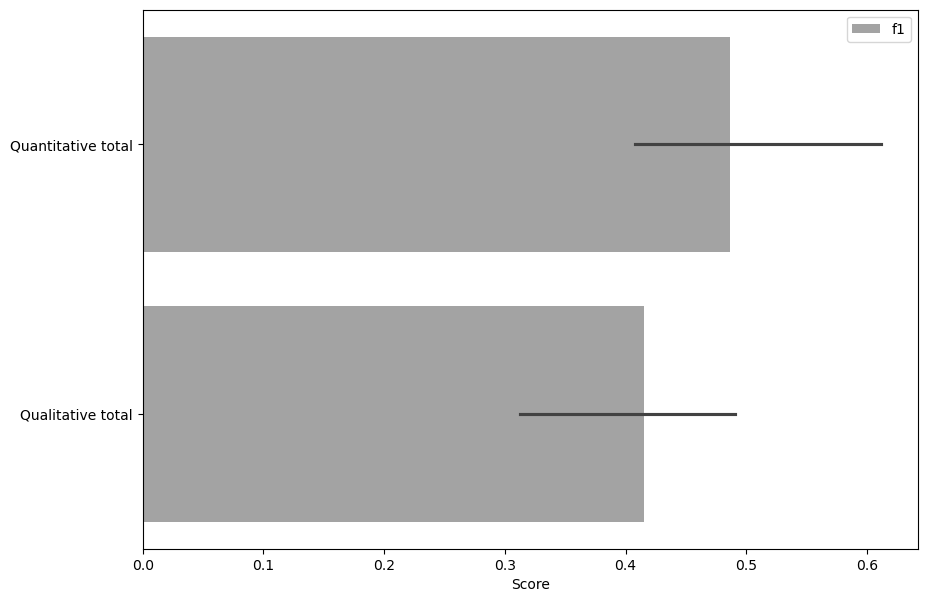

In [13]:
#plot sensitivity by repetition
fig, axes = plt.subplots(1, 1, figsize=(10, 7), sharey=False, sharex=False)
colors = ["#a3a3a3", "#6c6236"]
sns.barplot(data=f1_plot_met, x="value", y="quanti", hue="variable", errorbar=lambda x: (x.min(), x.max()), ax=axes, palette=colors)
axes.set_ylabel("")
axes.set_xlabel("Score")
legend = axes.get_legend()
legend.set_title("")
#fig.savefig(DATA_FIGURE / f"sens_analysis_diff_simulations.png", bbox_inches="tight", dpi=300)

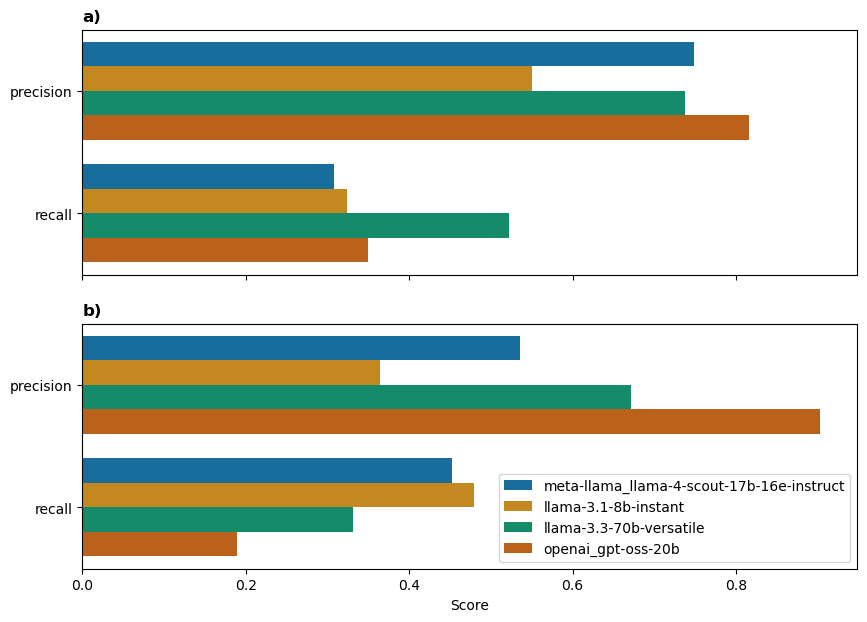

In [ ]:
#plot sensitivity by model
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharey=True, sharex=True)
cols = ["Quantitative total", "Qualitative total"]
labels=["a)", "b)"]
for i, col in enumerate(cols):
    sns.barplot(data=f1_plot_met[f1_plot_met["quanti"] == col], x="value", y="variable", hue="key", errorbar=lambda x: (x.min(), x.max()), ax=axes[i], palette="colorblind")# palette=colors
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Score")
    axes[i].set_title(labels[i], fontweight="bold", loc="left")
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_title("")
legend.set_loc("lower right")
fig.savefig(DATA_FIGURE / f"sens_analysis_diff_models.png", bbox_inches="tight", dpi=300)

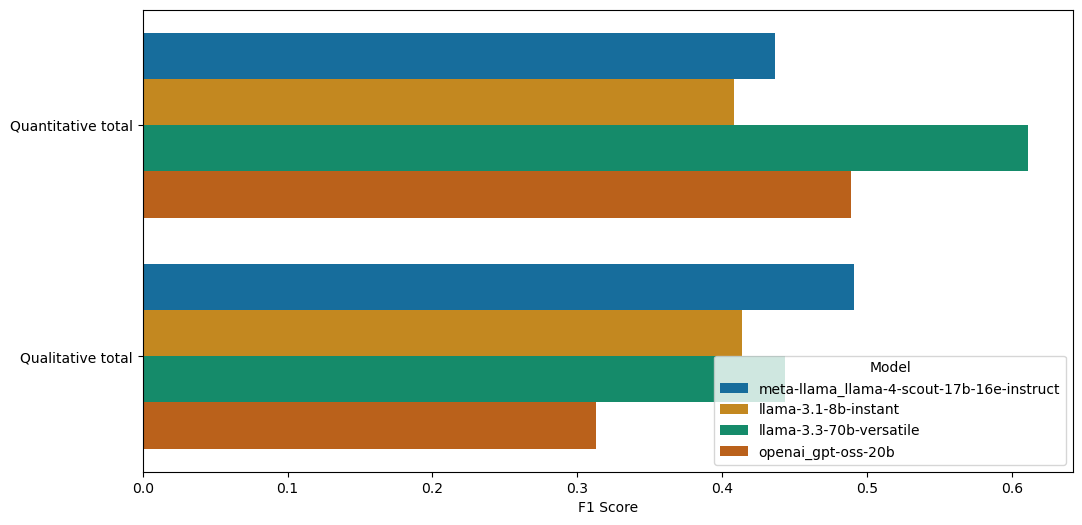

In [ ]:
#plot sensitivity by model
fig, axes = plt.subplots(1, 1, figsize=(12, 6), sharey=True, sharex=True)
cols = ["Quantitative total", "Qualitative total"]
labels=["a)", "b)"]

sns.barplot(data=f1_plot_met, x="value", y="quanti", hue="key", errorbar=lambda x: (x.min(), x.max()), ax=axes, palette="colorblind")# palette=colors
axes.set_ylabel("")
axes.set_xlabel("F1 Score")

legend = axes.get_legend()
legend.set_title("Model")
legend.set_loc("lower right")
#fig.savefig(DATA_FIGURE / f"F1_sens_analysis_diff_models.png", bbox_inches="tight", dpi=300)

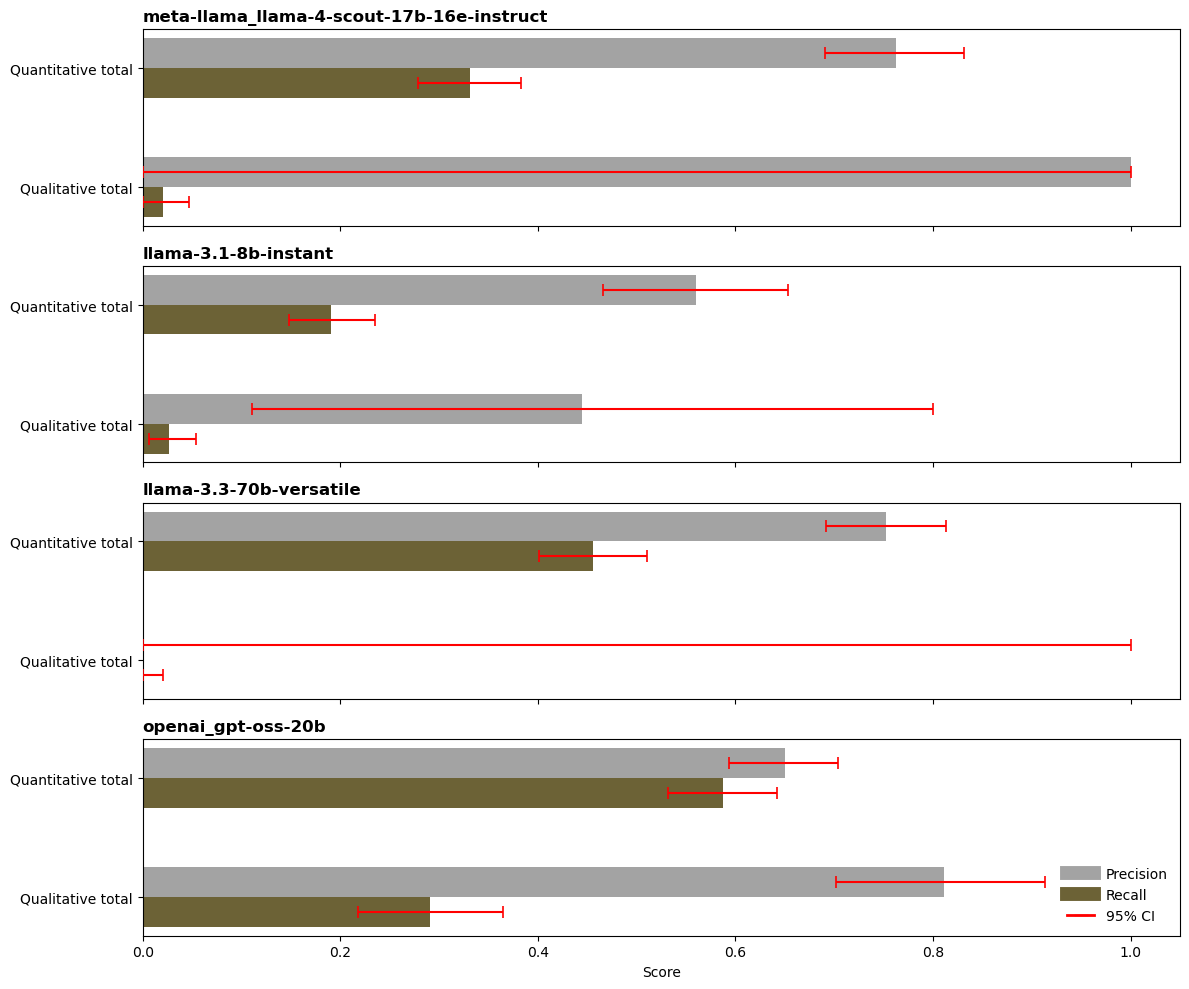

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

metrics = ["precision", "recall"]#"f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharey=False, sharex=True)

# --- Function to plot grouped bars with error bars ---
def plot_metrics_with_errorbars(ax, df, x_col, metrics, colors):
    n_metrics = len(metrics)
    y_positions = np.arange(len(df))
    height = 0.25  # controls bar thickness
    spacing = 0.3  # space between metric groups

    for i, metric in enumerate(metrics):
        # compute shifted y positions for each metric
        offset = (i - (n_metrics - 1)/2) * height
        y_shifted = y_positions + offset

        val = df[f"{metric}"]
        lower = df[f"{metric}_low_err"]
        upper = df[f"{metric}_high_err"]

        ax.barh(
            y_shifted,
            val,
            height=height,
            color=colors[i],
            label=metric.capitalize()
        )

        # Add horizontal error bars
        xerr = [lower, upper]
        ax.errorbar(
            val, y_shifted, xerr=xerr,
            fmt='none', ecolor='red',
            elinewidth=1.5, capsize=4, capthick=1.2, zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df[x_col])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)  # adjust if scores in [0,1]

# --- Plot bottom panel (all-level metrics) ---
for i, key in enumerate(filenames):
    f1_bs_key = f1_bs_all.loc[f1_bs_all["key"] == key]
    plot_metrics_with_errorbars(ax[i], f1_bs_key, "quanti", metrics, colors)

    # --- Plot top panel (by-key metrics) ---
    #plot_metrics_with_errorbars(ax[1], f1_bs_by_key, group_key, metrics, colors)

    # --- Labels ---
    ax[i].set_title(key, fontweight="bold", loc="left")

# --- Create combined legend handles ---
err_proxy = Line2D([0], [0], color='red', lw=2, marker='_', markersize=10, label='95% CI')
bars_proxy = [Line2D([0], [0], color=c, lw=10, label=m.capitalize()) for m, c in zip(metrics, colors)]
# --- Add legend ---
#ax[1].get_legend().remove()
ax[-1].set_xlabel("Score")
ax[-1].legend(handles=bars_proxy + [err_proxy], loc='lower right', frameon=False)#title="Metrics"

    #axi.set_title("a)", fontweight="bold", loc="left")

plt.tight_layout()
plt.show()

#fig.savefig(DATA_FIGURE / f"sens_analysis_diff_simulations.png", bbox_inches="tight", dpi=300)

In [38]:
from matplotlib.patches import bbox_artist
from matplotlib.pyplot import subplot
from src.plot_functions import add_avg_line

def plot_coverage_match_v2(df, subplot_col, hue_col, yvar, subplot_vars=None, xlabel="%", value_col="value", stack=False, hue_vars=None, palette=None, add_avg=True, fig=None, **kwargs):
    if not subplot_vars:
        subplot_vars = df[subplot_col].unique()
    if not hue_vars:
        hue_vars = df[hue_col].unique()
    if not palette:
        palette = sns.color_palette("colorblind", len(hue_vars))
    if fig is None:
        fig, ax = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True)
    else:
        ax = fig.get_axes()
    for i, val in enumerate(subplot_vars):
        ax_i = ax[i]
        val_df = df[df[subplot_col] == val]
        ipal = palette[2*i:2*(i+1)]

        if stack:
            # Compute stacked bar components manually
            # Aggregate by yvar and hue_col
            plot_df = (
                val_df
                .pivot_table(index=yvar, columns=hue_col, values=value_col, aggfunc='sum', fill_value=0)
                .reindex(columns=hue_vars)
            )

            # Initialize bottom at zero
            bottom = np.zeros(len(plot_df))

            # Draw each hue group as stacked bars
            for j, hue in enumerate(plot_df.columns):
                ax_i.barh(
                    plot_df.index,
                    plot_df[hue],
                    left=bottom,
                    color=ipal[j % len(ipal)],
                    label=hue,
                    edgecolor='black',
                    linewidth=0.5
                )
                bottom += plot_df[hue].values  # update bottom for next stack

            # Add legend only once (optional)
            if i == 0:
                ax_i.legend(title=hue_col)

        else:
            sns.barplot(
                data=val_df,
                x=value_col, y=yvar,
                hue=hue_col,
                hue_order=hue_vars,
                palette=ipal,
                ax=ax_i,
                **kwargs
            )
        #add average coverage line
        if add_avg:
            ax[i] = add_avg_line(val_df, ax[i], hue_col, yvar, value_col, hue_vars, ipal)
        ax[i].set_title(val)
        ax[i].set_ylabel(yvar)
        ax[i].set_xlabel(xlabel)
        ax[i].legend(loc="lower right")
    return fig, ax

def add_error_bars(ax, data_col, val_df, hue_col, hue_order, errors_df_val, ylabels):
    # --- Compute offsets for subbars ---
        # Each bar group has len(hue_order) bars, equally spaced
        n_hues = len(hue_order)
        bar_height = 0.8 / n_hues  # total bar thickness divided by subbars

        # offset positions from center of each category
        offsets = np.linspace(-0.4 + bar_height/2, 0.4 - bar_height/2, n_hues)

        # --- Add custom error bars for each subbar ---
        for cat_i, cat in enumerate(ylabels):#val_df[data_col].unique()
            for j, hue in enumerate(hue_order):
                subset = val_df[(val_df[data_col] == cat) & (val_df[hue_col] == hue)]
                if subset.empty:
                    continue
                true_val = subset["value"].values[0]

                # matching error row
                err_row = errors_df_val[(errors_df_val[data_col] == cat) & (errors_df_val[hue_col] == hue)].iloc[0]

                # y-position adjusted for hue offset
                y_pos = cat_i + offsets[j]

                # draw horizontal error bars
                xerr_min = max(0, true_val - err_row["err_low"])
                xerr_max = max(0, err_row["err_high"] - true_val)
                ax.errorbar(
                    x=true_val,
                    y=y_pos,
                    xerr=[[xerr_min], [xerr_max]],
                    fmt='none',
                    ecolor='red',
                    elinewidth=1.5,
                    capsize=4,
                    capthick=1.2,
                    zorder=5
                )
        return ax

In [ ]:
#prepare data
#coverage_df_match_subtype = coverage_df_match_subtype.loc[~coverage_df_match_subtype["impactSubtype"].isin(["DREF Allocation", "Targeted People", "Assisted People"])]


relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
coverage_df_match_subtype.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = coverage_df_match_subtype.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
#sort
#index = extracted_df.groupby("appealCode").head(1).sort_values("reportSize", ascending=False)["appealCode"]
#coverage_df_match_appeal["appealCode"] = pd.Categorical(coverage_df_match_appeal["appealCode"], categories=index, ordered=True)
#coverage_df_match_appeal = coverage_df_match_appeal.sort_values("appealCode") #sort by size
index = coverage_df_match_subtype.sort_values("nb extracted", ascending=False).index
coverage_df_match_subtype["sort score"] = coverage_df_match_subtype.groupby(["impactSubtype","quanti"])[["nb extracted"]].transform("sum").sum(axis=1)
# Sort each quanti group internally by the sort score
coverage_df_match_subtype = (
    coverage_df_match_subtype
    .sort_values(["quanti", "sort score"], ascending=[False, False])
)

#melt df for seaborn
coverage_df_match_appeal_melt = coverage_df_match_appeal.melt(id_vars=["appealCode","reportSize", "reportDate", "appealType", "quanti"])

#plot_df = coverage_df_match_yvar.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
coverage_df_match_subtype_melt = coverage_df_match_subtype.melt(id_vars=["impactSubtype", "quanti"])

coverage_df_match_melt = coverage_df_match.melt(id_vars=["quanti"])


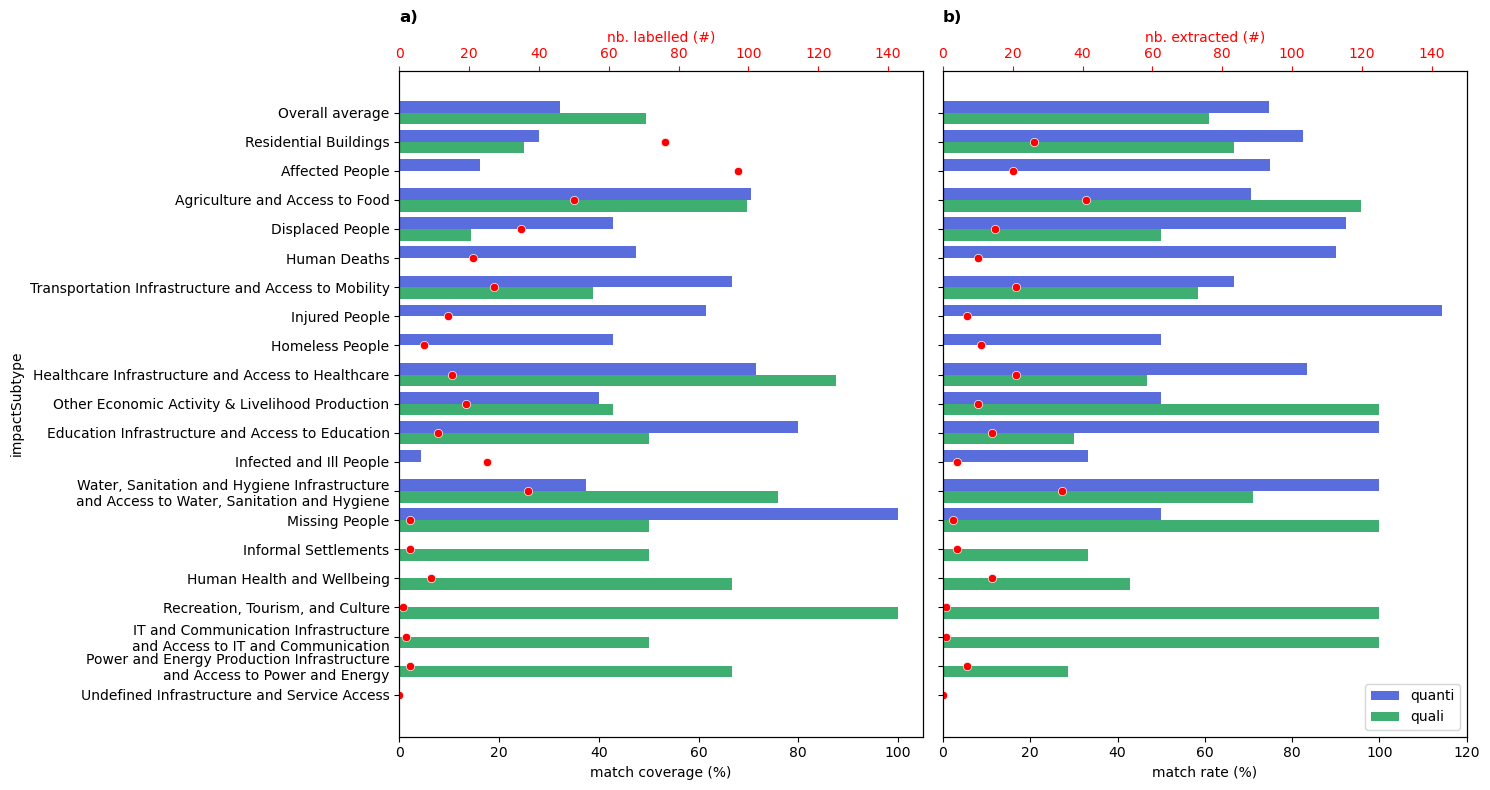

In [14]:
#choose plotting cols

subplot_vars = ["match coverage", "match rate"]#["nb labelled","nb matches", "nb garbage"]#["nb labelled","nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
yvar= "impactSubtype"
plot_df = coverage_df_match_subtype_melt
value_col = "value"
subplot_col = "variable"#"quanti""variable"
hue_col = "quanti"#"quanti""variable"
add_avg = True
add_secaxes = True
sec_vars = ["nb labelled", "nb extracted"]
stack = False
error_bar = False
errors_df = coverage_match_df_err
xlabels = [svar + " (%)" for svar in subplot_vars]#["#", "%", "%"]#["#", "#", "#"]#["%", "%"]#["#", "#", "#"]
secxlabels = ["nb. labelled (#)", "nb. extracted (#)"]
hue_order = ["quanti", "quali"] #["quanti", "quali"] ["match coverage", "match rate"]
#palette_rel = ["#978F8F", "#141212","#978F8F", "#141212"]
palette_rel = ["#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]
kwargs = {}#{"errorbar":("pi", 90)}

if add_avg:
    coverage_df_match_melt[yvar] ="Overall average"
    plot_df = pd.concat([coverage_df_match_melt, plot_df], axis=0).reset_index(drop=True)

fig, axes = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True, sharex=False)
fig, axes = plot_coverage_match_v2(plot_df[plot_df[hue_col].isin(hue_order)], subplot_col, hue_col, subplot_vars=subplot_vars, yvar=yvar, value_col=value_col, hue_vars=hue_order, stack=stack, palette=palette_rel, add_avg=False, fig=fig, **kwargs)
ylabels = [item.get_text() for item in axes[0].get_yticklabels()]
secaxes = []
if add_secaxes:
    for i, ax in enumerate(axes):
        val_df_scatter = plot_df[plot_df["variable"] == sec_vars[i]].groupby(yvar).sum()
        val_df_scatter = val_df_scatter.reindex(ylabels).reset_index()
        secax = ax.twiny()#ax.secondary_xaxis('top')
        secaxes.append(secax)
        sns.scatterplot(data=val_df_scatter, x=value_col, y=yvar, ax=secax.axes, color="r")
        secax.set_xlabel(secxlabels[i], color="r")
        secax.tick_params(axis='x', colors="r")
        secax.set_title("")
    secaxes[0].axes.set_title("")
    secaxes[1].axes.set_title("")
    secaxes[0].axes.set_xlim(0, 150)
    secaxes[1].axes.set_xlim(0, 150)
if error_bar:
    for i, val in enumerate(subplot_vars):
        val_df = plot_df[plot_df[subplot_col] == val]
        errors_df_val = errors_df[errors_df[subplot_col] == val]
        ax = axes[i]
        ax = add_error_bars(ax, yvar, val_df, hue_col, hue_order, errors_df_val, ylabels)

#[ax.set_xlabel(xlabels[i]) for i, ax in enumerate(axes)]
#for ax in axes:
#    ax.tick_params(axis='y', labelrotation=90)
[ax.set_xlabel(xlabels[i]) for i, ax in enumerate(axes)]
axes[0].set_title("")
axes[1].set_title("")
axes[1].set_ylabel("")
axes[0].set_title("a)", fontweight="bold", loc="left")
axes[1].set_title("b)", fontweight="bold", loc="left")
axes[0].get_legend().remove()
#fig.suptitle(f"Coverage matches by {yvar}\n{key}\nvalue_error_thresh={value_error_th}, sim_thresh={sim_th}")
fig.tight_layout()
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_{subplot_col}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=300)

In [15]:
plot_df

,quanti,variable,value,impactSubtype
0,quanti,nb labelled,304.000000,Overall average
1,quali,nb labelled,168.000000,Overall average
2,quanti,nb extracted,131.000000,Overall average
3,quali,nb extracted,136.000000,Overall average
4,quanti,coverage,43.092105,Overall average
...,...,...,...,...
413,quali,sort score,1.000000,IT and Communication Infrastructure\nand Acces...
414,quali,sort score,0.000000,Affected People
415,quali,sort score,0.000000,Injured People
416,quali,sort score,0.000000,Human Deaths


In [16]:
plot_df = coverage_df_match_appeal[coverage_df_match_appeal["variable"].isin(["match coverage", "drop rate"])]
fig, axes = plt.subplots(1, 1, figsize=(10, 7), sharey=False, sharex=False)
palette = sns.color_palette("colorblind", 2)
sns.boxplot(data=plot_df, x="variable", y="value", hue="quanti", orient="v", ax=axes, gap=0.1, palette=palette)
fig.tight_layout()
fig.savefig(DATA_FIGURE / f"boxplot_coverage_matches_by_{yvar}_{subplot_col}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=300)


KeyError: 'variable'

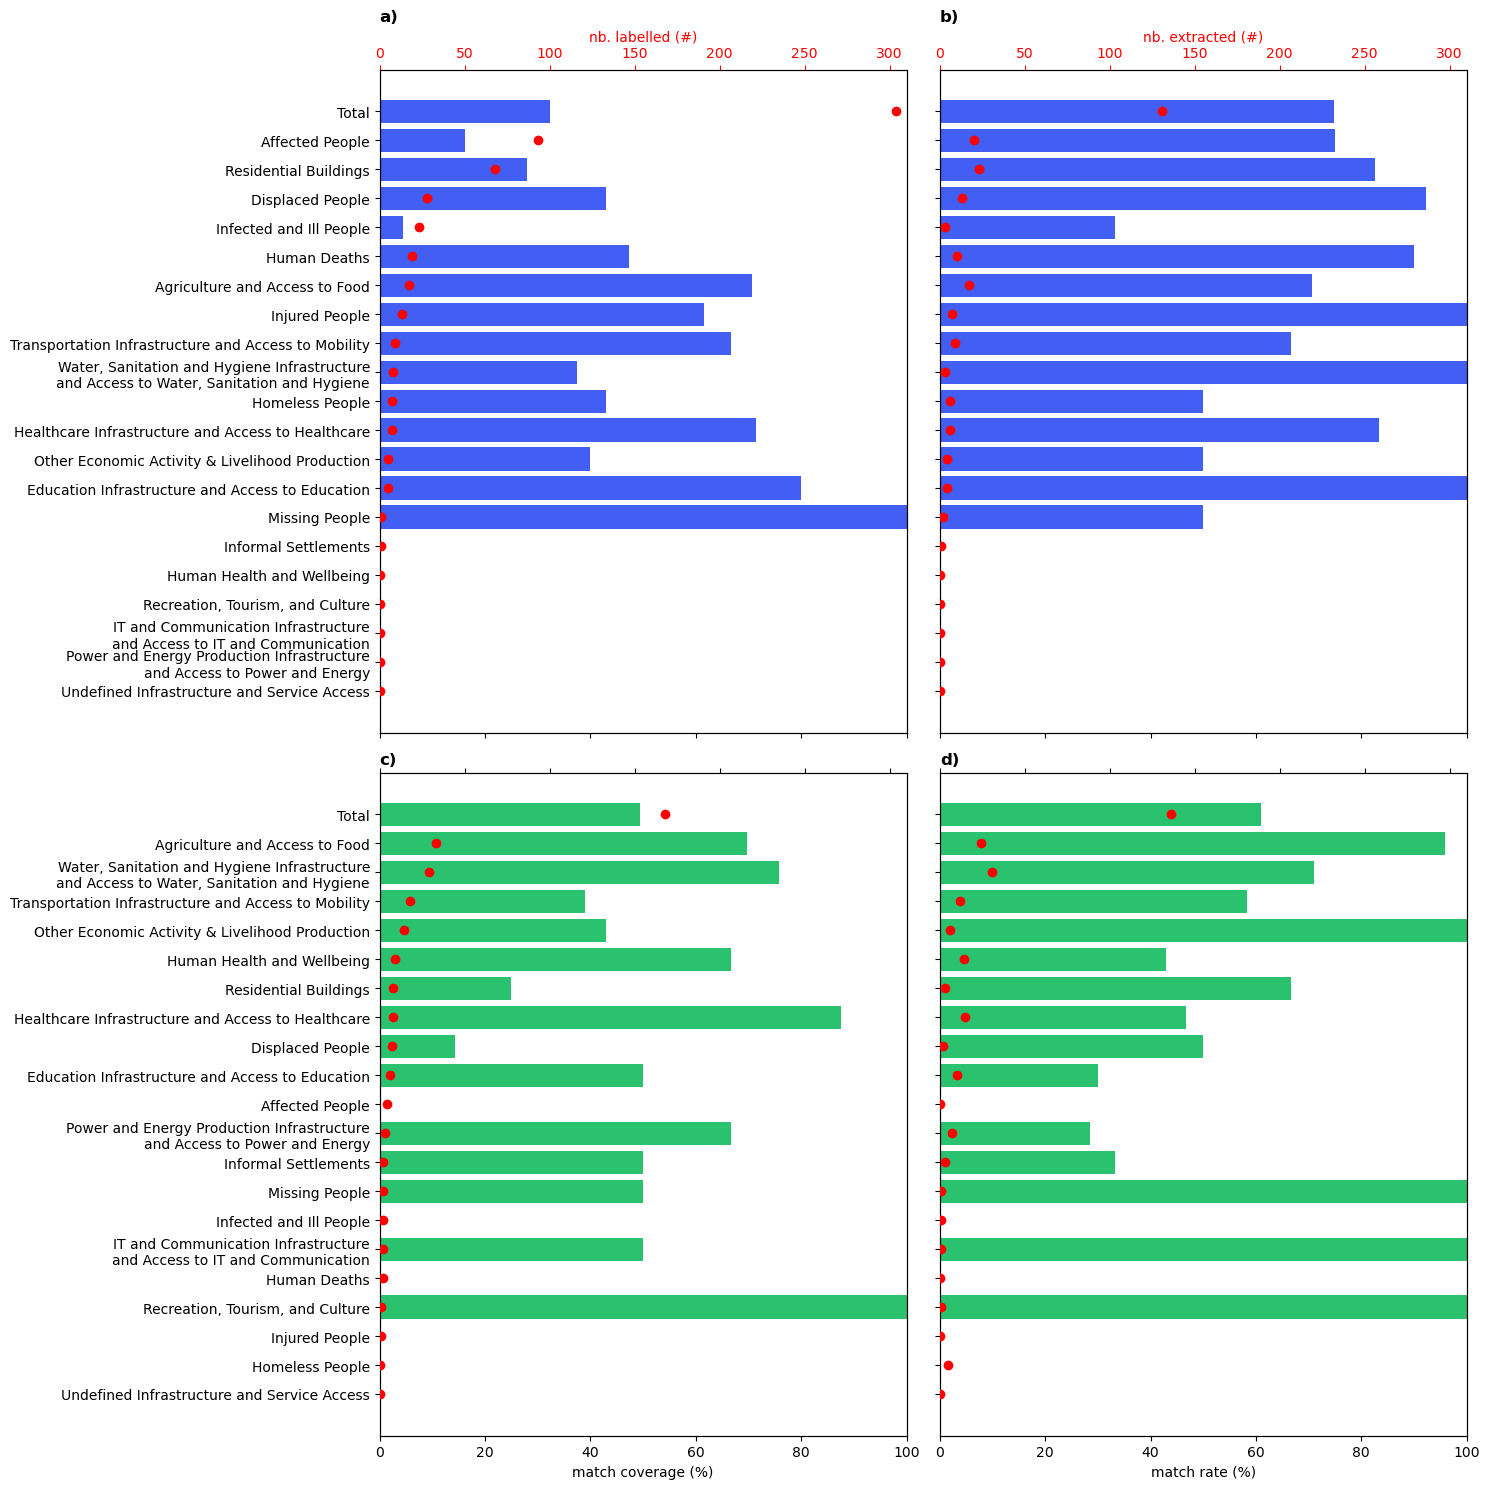

In [ ]:
#choose plotting cols
yvar= "impactSubtype"
plot_df = coverage_df_match_subtype.set_index(yvar)
top_bot = ["quanti", "quali"] #["quanti", "quali"] ["match coverage", "match rate"] #["quanti", "quali"] ["match coverage", "match rate"]
left_right = ["match coverage", "match rate"]#["nb labelled","nb matches", "nb garbage"]#["nb labelled","nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
sec_vars = ["nb labelled", "nb extracted"]

value_col = "value"
subplot_col = "quanti"#"quanti""variable"
hue_col = "quanti"#"quanti""variable"
add_avg = True
add_secaxes = True
stack = False
error_bar = False
errors_df = coverage_match_df_err
xlabels = [svar + " (%)" for svar in subplot_vars]#["#", "%", "%"]#["#", "#", "#"]#["%", "%"]#["#", "#", "#"]
secxlabels = ["nb. labelled (#)", "nb. extracted (#)"]
#palette_rel = ["#978F8F", "#141212","#978F8F", "#141212"]
palette_rel = ["#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]
kwargs = {}#{"errorbar":("pi", 90)}

if add_avg:
    coverage_df_match[yvar] = "Total"
    plot_df = pd.concat([coverage_df_match.set_index(yvar), plot_df], axis=0)

fig, axes = plt.subplots(len(hue_order), len(subplot_vars), figsize=(15, 15), sharey=False, sharex=True)
for i, val in enumerate(top_bot):
    val_df = plot_df[plot_df["quanti"] == val].sort_values("nb labelled", ascending=False).fillna(0)
    ax = axes[i,0]
    ax.barh(val_df.index, val_df[left_right[0]], color=palette_rel[i])
    ax.invert_yaxis()  # keep the largest value on top

    axes[i,1].barh(val_df.index, val_df[left_right[1]], color=palette_rel[i])
    axes[i,1].set_yticklabels([])
    axes[i,1].invert_yaxis()
    #axes[i,0].set_autoscalex_on(False)
    #axes[i,1].set_autoscalex_on(False)
    axes[i,0].set_xlim(0, 100)
    axes[i,1].set_xlim(0, 100)

secaxes = []
# --- Add secondary x-axes (top) with red scatterplots ---
if add_secaxes:
    for i in range(len(top_bot)):             # rows
        for j in range(len(left_right)):      # columns
            ax = axes[i, j]
            val = subplot_vars[j]
            ylabels = [item.get_text() for item in axes[i, 0].get_yticklabels()]
            # Extract the corresponding data
            val_df_scatter = plot_df.loc[plot_df["quanti"] == top_bot[i], sec_vars[j]].reindex(ylabels)
            secax = ax.twiny()
            secaxes.append(secax)

            secax.scatter(
                x=val_df_scatter,
                y=val_df_scatter.index,
                color="r",
                zorder=5
            )

            if i==0:
                secax.set_xlabel(secxlabels[j], color="r")
                secax.tick_params(axis='x', colors="r")
            else:
                secax.set_xlabel("")
                secax.tick_params(axis='x', which='both', labelbottom=False, labeltop=False)
            secax.set_title("")
            #secax.set_autoscalex_on(False)
            secax.set_xlim(0, 310)
            #secax.set_xticks(np.arange(0, 400, 50))


# --- Add error bars (horizontal) ---
if error_bar:
    for i in range(len(top_bot)):             # rows
        for j in range(len(left_right)):      # columns
            val = subplot_vars[j]
            ax = axes[i, j]
            val_df = plot_df[(plot_df[subplot_col] == val) & (plot_df["quanti"] == top_bot[i])]
            errors_df_val = errors_df[(errors_df[subplot_col] == val) & (errors_df["quanti"] == top_bot[i])]
            ax = add_error_bars(ax, yvar, val_df, hue_col, hue_order, errors_df_val, ylabels)

# --- Labeling, titles, legends ---
for j, ax_col in enumerate(axes[1, :]):
    ax_col.set_xlabel(xlabels[j])

for i in range(len(hue_order)):
    for j in range(len(subplot_vars)):
        axes[i, j].set_title("")

axes[0, 0].set_title("a)", fontweight="bold", loc="left")
axes[0, 1].set_title("b)", fontweight="bold", loc="left")
axes[1, 0].set_title("c)", fontweight="bold", loc="left")
axes[1, 1].set_title("d)", fontweight="bold", loc="left")

# remove redundant ylabel and legends
for i in range(len(hue_order)):
    axes[i, 1].set_ylabel("")
    if axes[i, 0].get_legend() is not None:
        axes[i, 0].get_legend().remove()

fig.tight_layout()

fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_var_sep_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=300)

## Sensitivity to external variables

In [ ]:
## add other variables useful for analysis
#report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

#report type
file_path = DATA_IN_JSONS / "preproc_filtered_report_types_nat_hazards_bugfix_v250925.csv"#'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


#add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])


In [ ]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)


/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

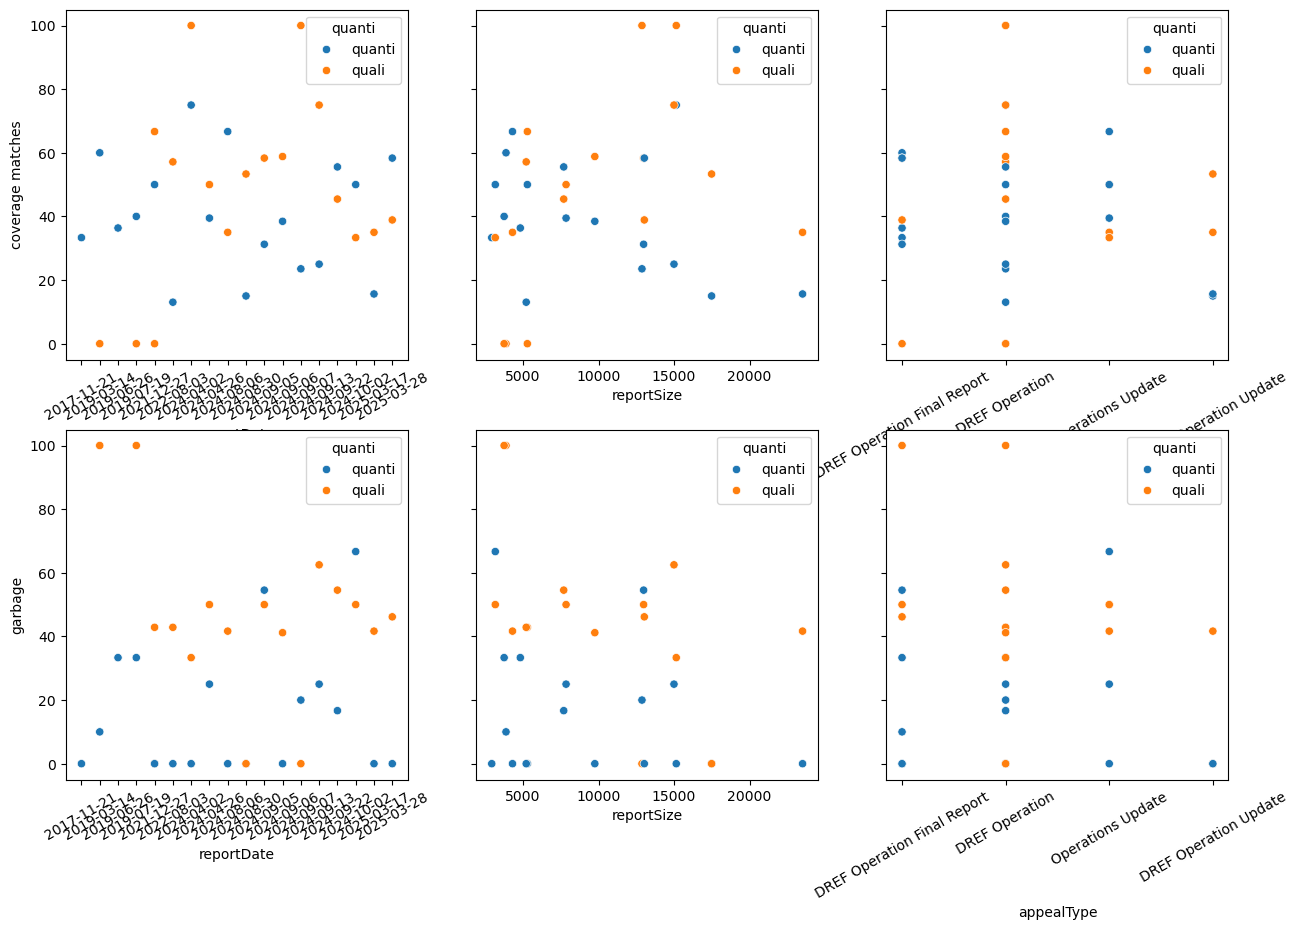

In [12]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [150]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

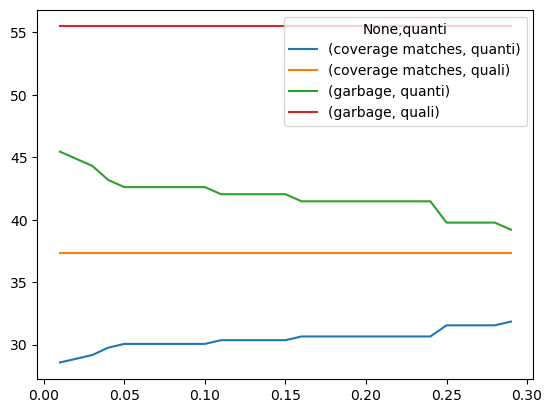

In [151]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

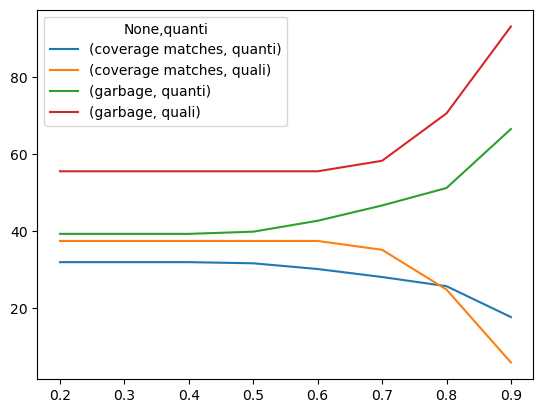

In [152]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [4]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


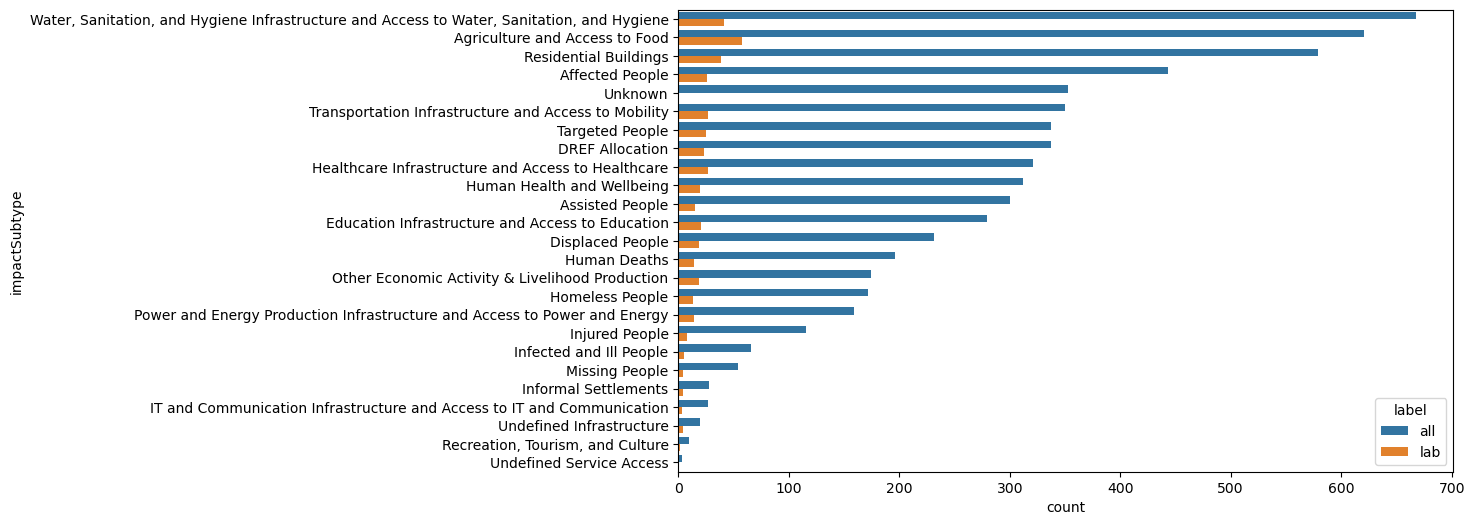

In [5]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
